# Image Super-Resolution (BasicGAN / SRGAN / ESRGAN)
# Optimised for Google Colab — Runtime ▶ Change runtime type ▶ GPU (T4)


In [1]:
# Colab already ships with PyTorch, torchvision, PIL, matplotlib, numpy.
# Run this cell only if any import below fails.
# !pip install -q torch torchvision Pillow matplotlib numpy


In [2]:
import torch
assert torch.cuda.is_available(), (
    "GPU not found! Go to Runtime > Change runtime type > Hardware Accelerator > GPU"
)
print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ─── Option A: Kaggle API (recommended) ───────────────────────────────────────
# 1. Go to kaggle.com > Account > Create New API Token  → downloads kaggle.json
# 2. Upload kaggle.json when the file picker appears below.
import os
from google.colab import files

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Upload your kaggle.json …")
    uploaded = files.upload()          # pick kaggle.json
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename(list(uploaded.keys())[0], '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download & unzip dataset
KAGGLE_DATASET = 'adityachandrasekhar/image-super-resolution'
DEST = '/content/sr_dataset'
if not os.path.isdir(DEST):
    os.makedirs(DEST, exist_ok=True)
    os.system(f'kaggle datasets download -d {KAGGLE_DATASET} -p {DEST} --unzip')
    print("Dataset ready at", DEST)
else:
    print("Dataset already present at", DEST)

# ─── Option B: already on Drive ───────────────────────────────────────────────
# If you copied the dataset to your Drive, skip the block above and set:
# DEST = '/content/drive/MyDrive/sr_dataset'


Upload your kaggle.json …


Saving kaggle.json to kaggle.json
Dataset ready at /content/sr_dataset


In [5]:
import os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── AMP: works with both old and new PyTorch ───────────────────────────────────
try:
    from torch.amp import autocast, GradScaler          # PyTorch ≥ 2.0
    AMP_DEVICE = 'cuda'
except ImportError:
    from torch.cuda.amp import autocast, GradScaler     # PyTorch < 2.0
    AMP_DEVICE = None   # autocast() takes no device arg in old API

def amp_autocast():
    """Wrapper so the rest of the code never has to worry about the API version."""
    return autocast(AMP_DEVICE) if AMP_DEVICE else autocast()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [9]:
DATASET_PATH = os.path.join(DEST, 'dataset')          # set above; change if you used Option B
RAW_HIGH_RES = os.path.join(DATASET_PATH, 'Raw Data', 'high_res')
RAW_LOW_RES  = os.path.join(DATASET_PATH, 'Raw Data', 'low_res')
TRAIN_HIGH   = os.path.join(DATASET_PATH, 'train', 'high_res')
TRAIN_LOW    = os.path.join(DATASET_PATH, 'train', 'low_res')
VAL_HIGH     = os.path.join(DATASET_PATH, 'val',   'high_res')
VAL_LOW      = os.path.join(DATASET_PATH, 'val',   'low_res')

HIGH_RES = 128
LOW_RES  = 32
BATCH    = 8
EPOCHS   = 30
LR       = 1e-4

# Quick sanity check
for d in [TRAIN_HIGH, TRAIN_LOW, VAL_HIGH, VAL_LOW]:
    n = len(os.listdir(d)) if os.path.isdir(d) else 0
    print(f'{d}: {n} files')


/content/sr_dataset/dataset/train/high_res: 685 files
/content/sr_dataset/dataset/train/low_res: 685 files
/content/sr_dataset/dataset/val/high_res: 170 files
/content/sr_dataset/dataset/val/low_res: 170 files


In [11]:
class SRDataset(Dataset):
    def __init__(self, hr_dir, lr_dir):
        self.hr_files = sorted([f for f in os.listdir(hr_dir)
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.lr_files = sorted([f for f in os.listdir(lr_dir)
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.hr_dir = hr_dir
        self.lr_dir = lr_dir
        self.hr_transform = transforms.Compose([
            transforms.Resize((HIGH_RES, HIGH_RES)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
        self.lr_transform = transforms.Compose([
            transforms.Resize((LOW_RES, LOW_RES)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return min(len(self.hr_files), len(self.lr_files))

    def __getitem__(self, idx):
        hr = Image.open(os.path.join(self.hr_dir, self.hr_files[idx])).convert('RGB')
        lr = Image.open(os.path.join(self.lr_dir, self.lr_files[idx])).convert('RGB')
        return self.lr_transform(lr), self.hr_transform(hr)

# num_workers=2 is safe on Colab (avoids DataLoader worker spawn issues)
train_ds = SRDataset(TRAIN_HIGH, TRAIN_LOW)
val_ds   = SRDataset(VAL_HIGH,   VAL_LOW)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')


Train: 685 | Val: 170


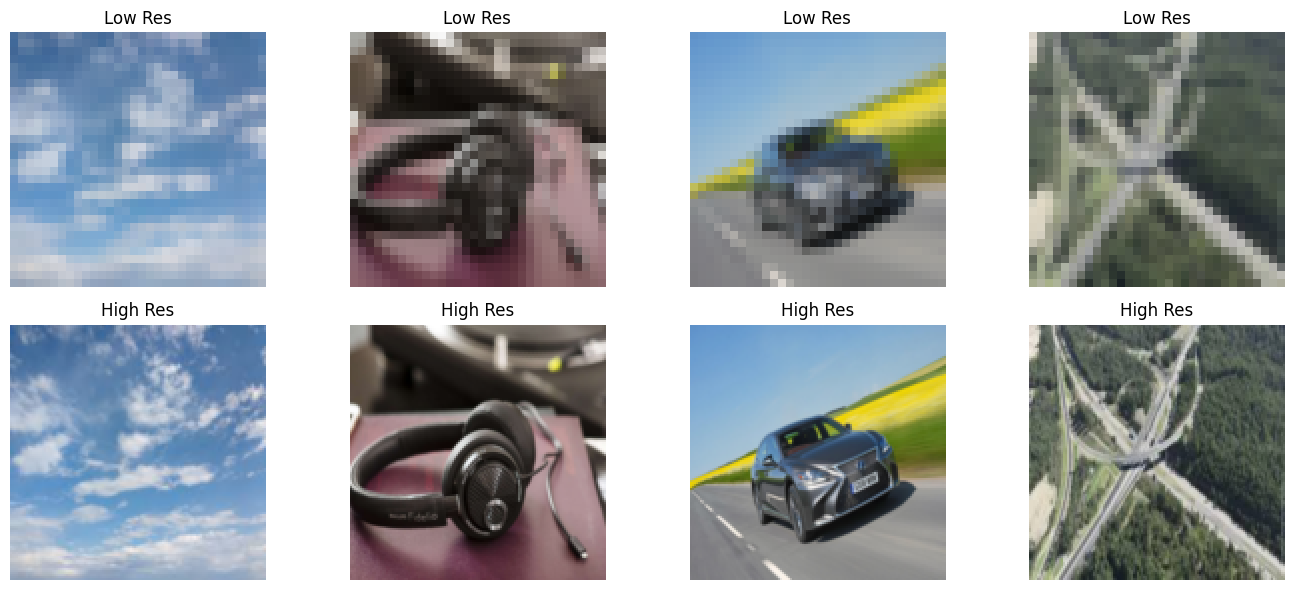

In [12]:
lr_batch, hr_batch = next(iter(train_dl))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    axes[0, i].imshow(lr_batch[i].permute(1, 2, 0).numpy() * 0.5 + 0.5)
    axes[0, i].set_title('Low Res'); axes[0, i].axis('off')
    axes[1, i].imshow(hr_batch[i].permute(1, 2, 0).numpy() * 0.5 + 0.5)
    axes[1, i].set_title('High Res'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()


## Basic GAN for Super Resolution


In [13]:
class BasicGenerator(nn.Module):
    def __init__(self, scale=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 9, 1, 4), nn.PReLU(),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.PReLU(),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.PReLU(),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
            nn.Conv2d(64, 3, 9, 1, 4), nn.Tanh()
        )
    def forward(self, x): return self.net(x)

class BasicDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ic, oc, stride=1):
            return nn.Sequential(nn.Conv2d(ic, oc, 3, stride, 1),
                                 nn.BatchNorm2d(oc), nn.LeakyReLU(0.2))
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.LeakyReLU(0.2),
            block(64, 64, 2), block(64, 128), block(128, 128, 2),
            block(128, 256), block(256, 256, 2), block(256, 512), block(512, 512, 2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.Linear(1024, 1)
        )
    def forward(self, x): return self.net(x)


In [14]:
def train_basic_gan(epochs=EPOCHS):
    G = BasicGenerator().to(device)
    D = BasicDiscriminator().to(device)
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.9, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.9, 0.999))
    bce = nn.BCEWithLogitsLoss()
    l1  = nn.L1Loss()
    scaler = GradScaler()
    g_losses, d_losses = [], []

    for epoch in range(epochs):
        G.train(); D.train()
        g_ep, d_ep = 0, 0
        for lr_imgs, hr_imgs in train_dl:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            real_lbl = torch.ones(lr_imgs.size(0),  1, device=device)
            fake_lbl = torch.zeros(lr_imgs.size(0), 1, device=device)

            opt_D.zero_grad()
            with amp_autocast():
                fake   = G(lr_imgs).detach()
                d_loss = bce(D(hr_imgs), real_lbl) + bce(D(fake), fake_lbl)
            scaler.scale(d_loss).backward()
            scaler.step(opt_D)

            opt_G.zero_grad()
            with amp_autocast():
                fake   = G(lr_imgs)
                g_loss = bce(D(fake), real_lbl) + 10 * l1(fake, hr_imgs)
            scaler.scale(g_loss).backward()
            scaler.step(opt_G)
            scaler.update()
            g_ep += g_loss.item(); d_ep += d_loss.item()

        g_losses.append(g_ep / len(train_dl))
        d_losses.append(d_ep / len(train_dl))
        if (epoch + 1) % 5 == 0:
            print(f'[BasicGAN] Epoch [{epoch+1}/{epochs}]  '
                  f'G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}')

    return G, g_losses, d_losses

basic_G, basic_g_loss, basic_d_loss = train_basic_gan()


[BasicGAN] Epoch [5/30]  G: 5.9976  D: 0.2119
[BasicGAN] Epoch [10/30]  G: 6.1221  D: 0.0682
[BasicGAN] Epoch [15/30]  G: 6.9248  D: 0.2125
[BasicGAN] Epoch [20/30]  G: 6.3385  D: 0.4052
[BasicGAN] Epoch [25/30]  G: 7.5661  D: 0.0123
[BasicGAN] Epoch [30/30]  G: 7.9668  D: 0.0212


## SRGAN

In [15]:
class ResBlock(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1), nn.BatchNorm2d(ch), nn.PReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1), nn.BatchNorm2d(ch)
        )
    def forward(self, x): return x + self.block(x)

class SRGANGenerator(nn.Module):
    def __init__(self, n_res=16):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(3, 64, 9, 1, 4), nn.PReLU())
        self.res  = nn.Sequential(*[ResBlock() for _ in range(n_res)])
        self.mid  = nn.Sequential(nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64))
        self.up   = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
            nn.Conv2d(64, 3,   9, 1, 4), nn.Tanh()
        )
    def forward(self, x):
        h = self.head(x)
        return self.up(h + self.mid(self.res(h)))

class SRGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, s=1):
            return [nn.Conv2d(ic, oc, 3, s, 1), nn.BatchNorm2d(oc), nn.LeakyReLU(0.2, True)]
        layers = [nn.Conv2d(3, 64, 3, 1, 1), nn.LeakyReLU(0.2, True)]
        for ic, oc, s in [(64,64,2),(64,128,1),(128,128,2),(128,256,1),
                          (256,256,2),(256,512,1),(512,512,2)]:
            layers += blk(ic, oc, s)
        layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                   nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.Linear(1024, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class VGGLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features[:35].eval().to(device)
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg = vgg
        self.mse = nn.MSELoss()
    def forward(self, sr, hr):
        return self.mse(self.vgg(sr), self.vgg(hr))


In [16]:
def train_srgan(epochs=EPOCHS):
    G = SRGANGenerator().to(device)
    D = SRGANDiscriminator().to(device)
    vgg_loss = VGGLoss()
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.9, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.9, 0.999))
    bce   = nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    g_losses, d_losses = [], []

    print('Pretraining Generator (MSE)…')
    mse = nn.MSELoss()
    for _ in range(5):
        for lr_imgs, hr_imgs in train_dl:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            opt_G.zero_grad()
            with amp_autocast(): loss = mse(G(lr_imgs), hr_imgs)
            scaler.scale(loss).backward()
            scaler.step(opt_G); scaler.update()
    print('Pretraining done. Starting adversarial training…')

    for epoch in range(epochs):
        G.train(); D.train()
        g_ep, d_ep = 0, 0
        for lr_imgs, hr_imgs in train_dl:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            real_lbl = torch.ones(lr_imgs.size(0),  1, device=device)
            fake_lbl = torch.zeros(lr_imgs.size(0), 1, device=device)

            opt_D.zero_grad()
            with amp_autocast():
                sr     = G(lr_imgs).detach()
                d_loss = bce(D(hr_imgs), real_lbl) + bce(D(sr), fake_lbl)
            scaler.scale(d_loss).backward()
            scaler.step(opt_D)

            opt_G.zero_grad()
            with amp_autocast():
                sr     = G(lr_imgs)
                g_loss = 1e-3 * bce(D(sr), real_lbl) + vgg_loss(sr, hr_imgs)
            scaler.scale(g_loss).backward()
            scaler.step(opt_G)
            scaler.update()
            g_ep += g_loss.item(); d_ep += d_loss.item()

        g_losses.append(g_ep / len(train_dl))
        d_losses.append(d_ep / len(train_dl))
        if (epoch + 1) % 5 == 0:
            print(f'[SRGAN] Epoch [{epoch+1}/{epochs}]  '
                  f'G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}')

    return G, g_losses, d_losses

srgan_G, srgan_g_loss, srgan_d_loss = train_srgan()


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 184MB/s]


Pretraining Generator (MSE)…
Pretraining done. Starting adversarial training…
[SRGAN] Epoch [5/30]  G: 6.9335  D: 0.1411
[SRGAN] Epoch [10/30]  G: 5.2794  D: 0.1523
[SRGAN] Epoch [15/30]  G: 4.2607  D: 0.0057
[SRGAN] Epoch [20/30]  G: 3.7116  D: 0.2199
[SRGAN] Epoch [25/30]  G: 3.4102  D: 0.0034
[SRGAN] Epoch [30/30]  G: 2.9915  D: 0.0022


## ESRGAN

In [17]:
class DenseBlock(nn.Module):
    def __init__(self, ch=64, gc=32):
        super().__init__()
        self.c1 = nn.Sequential(nn.Conv2d(ch,       gc, 3, 1, 1), nn.LeakyReLU(0.2, True))
        self.c2 = nn.Sequential(nn.Conv2d(ch+gc,    gc, 3, 1, 1), nn.LeakyReLU(0.2, True))
        self.c3 = nn.Sequential(nn.Conv2d(ch+2*gc,  gc, 3, 1, 1), nn.LeakyReLU(0.2, True))
        self.c4 = nn.Sequential(nn.Conv2d(ch+3*gc,  gc, 3, 1, 1), nn.LeakyReLU(0.2, True))
        self.c5 = nn.Conv2d(ch+4*gc, ch, 3, 1, 1)
    def forward(self, x):
        x1 = self.c1(x)
        x2 = self.c2(torch.cat([x, x1], 1))
        x3 = self.c3(torch.cat([x, x1, x2], 1))
        x4 = self.c4(torch.cat([x, x1, x2, x3], 1))
        return x + 0.2 * self.c5(torch.cat([x, x1, x2, x3, x4], 1))

class RRDB(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.db1 = DenseBlock(ch); self.db2 = DenseBlock(ch); self.db3 = DenseBlock(ch)
    def forward(self, x): return x + 0.2 * self.db3(self.db2(self.db1(x)))

class ESRGANGenerator(nn.Module):
    def __init__(self, n_rrdb=8):
        super().__init__()
        self.head     = nn.Conv2d(3, 64, 3, 1, 1)
        self.body     = nn.Sequential(*[RRDB() for _ in range(n_rrdb)])
        self.body_out = nn.Conv2d(64, 64, 3, 1, 1)
        self.up = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 64,  3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 3,   3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        h = self.head(x)
        return self.up(h + self.body_out(self.body(h)))

class ESRGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, s=1, bn=True):
            layers = [nn.Conv2d(ic, oc, 3, s, 1)]
            if bn: layers.append(nn.BatchNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, True))
            return layers
        layers = blk(3, 64, bn=False)
        for ic, oc, s in [(64,64,2),(64,128,1),(128,128,2),(128,256,1),
                          (256,256,2),(256,512,1),(512,512,2)]:
            layers += blk(ic, oc, s)
        layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                   nn.Linear(512, 100), nn.LeakyReLU(0.2), nn.Linear(100, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


In [18]:
def train_esrgan(epochs=EPOCHS):
    G = ESRGANGenerator().to(device)
    D = ESRGANDiscriminator().to(device)
    vgg_loss = VGGLoss()
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.9, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.9, 0.999))
    sch_G = optim.lr_scheduler.MultiStepLR(opt_G, milestones=[epochs//2, epochs*3//4], gamma=0.5)
    sch_D = optim.lr_scheduler.MultiStepLR(opt_D, milestones=[epochs//2, epochs*3//4], gamma=0.5)
    bce   = nn.BCEWithLogitsLoss()
    l1    = nn.L1Loss()
    scaler = GradScaler()
    g_losses, d_losses = [], []

    print('Pretraining ESRGAN Generator (L1)…')
    for _ in range(5):
        for lr_imgs, hr_imgs in train_dl:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            opt_G.zero_grad()
            with amp_autocast(): loss = l1(G(lr_imgs), hr_imgs)
            scaler.scale(loss).backward()
            scaler.step(opt_G); scaler.update()
    print('Pretraining done.')

    for epoch in range(epochs):
        G.train(); D.train()
        g_ep, d_ep = 0, 0
        for lr_imgs, hr_imgs in train_dl:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            bs = lr_imgs.size(0)

            # Relativistic GAN — D step
            opt_D.zero_grad()
            with amp_autocast():
                sr       = G(lr_imgs).detach()
                real_out = D(hr_imgs)
                fake_out = D(sr)
                d_loss   = (bce(real_out - fake_out.mean(),
                                torch.ones(bs,  1, device=device)) +
                            bce(fake_out - real_out.mean(),
                                torch.zeros(bs, 1, device=device))) / 2
            scaler.scale(d_loss).backward()
            scaler.step(opt_D)

            # G step
            opt_G.zero_grad()
            with amp_autocast():
                sr       = G(lr_imgs)
                real_out = D(hr_imgs).detach()
                fake_out = D(sr)
                gan_loss = (bce(real_out - fake_out.mean(),
                                torch.zeros(bs, 1, device=device)) +
                            bce(fake_out - real_out.mean(),
                                torch.ones(bs,  1, device=device))) / 2
                g_loss   = 5e-3 * gan_loss + 1e-2 * vgg_loss(sr, hr_imgs) + l1(sr, hr_imgs)
            scaler.scale(g_loss).backward()
            scaler.step(opt_G)
            scaler.update()
            g_ep += g_loss.item(); d_ep += d_loss.item()

        sch_G.step(); sch_D.step()
        g_losses.append(g_ep / len(train_dl))
        d_losses.append(d_ep / len(train_dl))
        if (epoch + 1) % 5 == 0:
            print(f'[ESRGAN] Epoch [{epoch+1}/{epochs}]  '
                  f'G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}')

    return G, g_losses, d_losses

esrgan_G, esrgan_g_loss, esrgan_d_loss = train_esrgan()


Pretraining ESRGAN Generator (L1)…
Pretraining done.
[ESRGAN] Epoch [5/30]  G: 0.1587  D: 0.0204
[ESRGAN] Epoch [10/30]  G: 0.1676  D: 0.0137
[ESRGAN] Epoch [15/30]  G: 0.1611  D: 0.0363
[ESRGAN] Epoch [20/30]  G: 0.1677  D: 0.0242
[ESRGAN] Epoch [25/30]  G: 0.1818  D: 0.0901
[ESRGAN] Epoch [30/30]  G: 0.1819  D: 0.0294


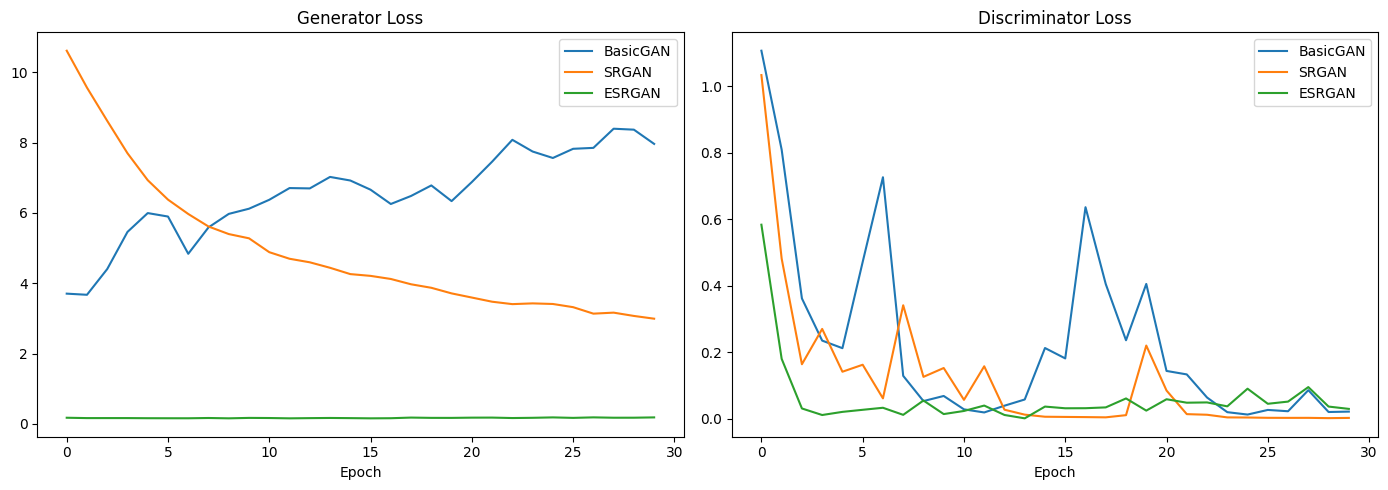

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for losses, label in [(basic_g_loss, 'BasicGAN'), (srgan_g_loss, 'SRGAN'), (esrgan_g_loss, 'ESRGAN')]:
    axes[0].plot(losses, label=label)
axes[0].set_title('Generator Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

for losses, label in [(basic_d_loss, 'BasicGAN'), (srgan_d_loss, 'SRGAN'), (esrgan_d_loss, 'ESRGAN')]:
    axes[1].plot(losses, label=label)
axes[1].set_title('Discriminator Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()


In [20]:
def compute_psnr(sr, hr):
    mse = torch.mean((sr - hr) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse)).item()

def evaluate(model, dataloader):
    model.eval()
    psnr_scores = []
    with torch.no_grad():
        for lr_imgs, hr_imgs in dataloader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            sr = model(lr_imgs)
            for i in range(sr.size(0)):
                psnr_scores.append(compute_psnr(
                    (sr[i].clamp(-1, 1) + 1) / 2,
                    (hr_imgs[i]          + 1) / 2
                ))
    return np.mean(psnr_scores)

psnr_basic  = evaluate(basic_G,  val_dl)
psnr_srgan  = evaluate(srgan_G,  val_dl)
psnr_esrgan = evaluate(esrgan_G, val_dl)

print(f'BasicGAN PSNR : {psnr_basic:.2f} dB')
print(f'SRGAN    PSNR : {psnr_srgan:.2f} dB')
print(f'ESRGAN   PSNR : {psnr_esrgan:.2f} dB')


BasicGAN PSNR : 18.47 dB
SRGAN    PSNR : 17.59 dB
ESRGAN   PSNR : 22.12 dB


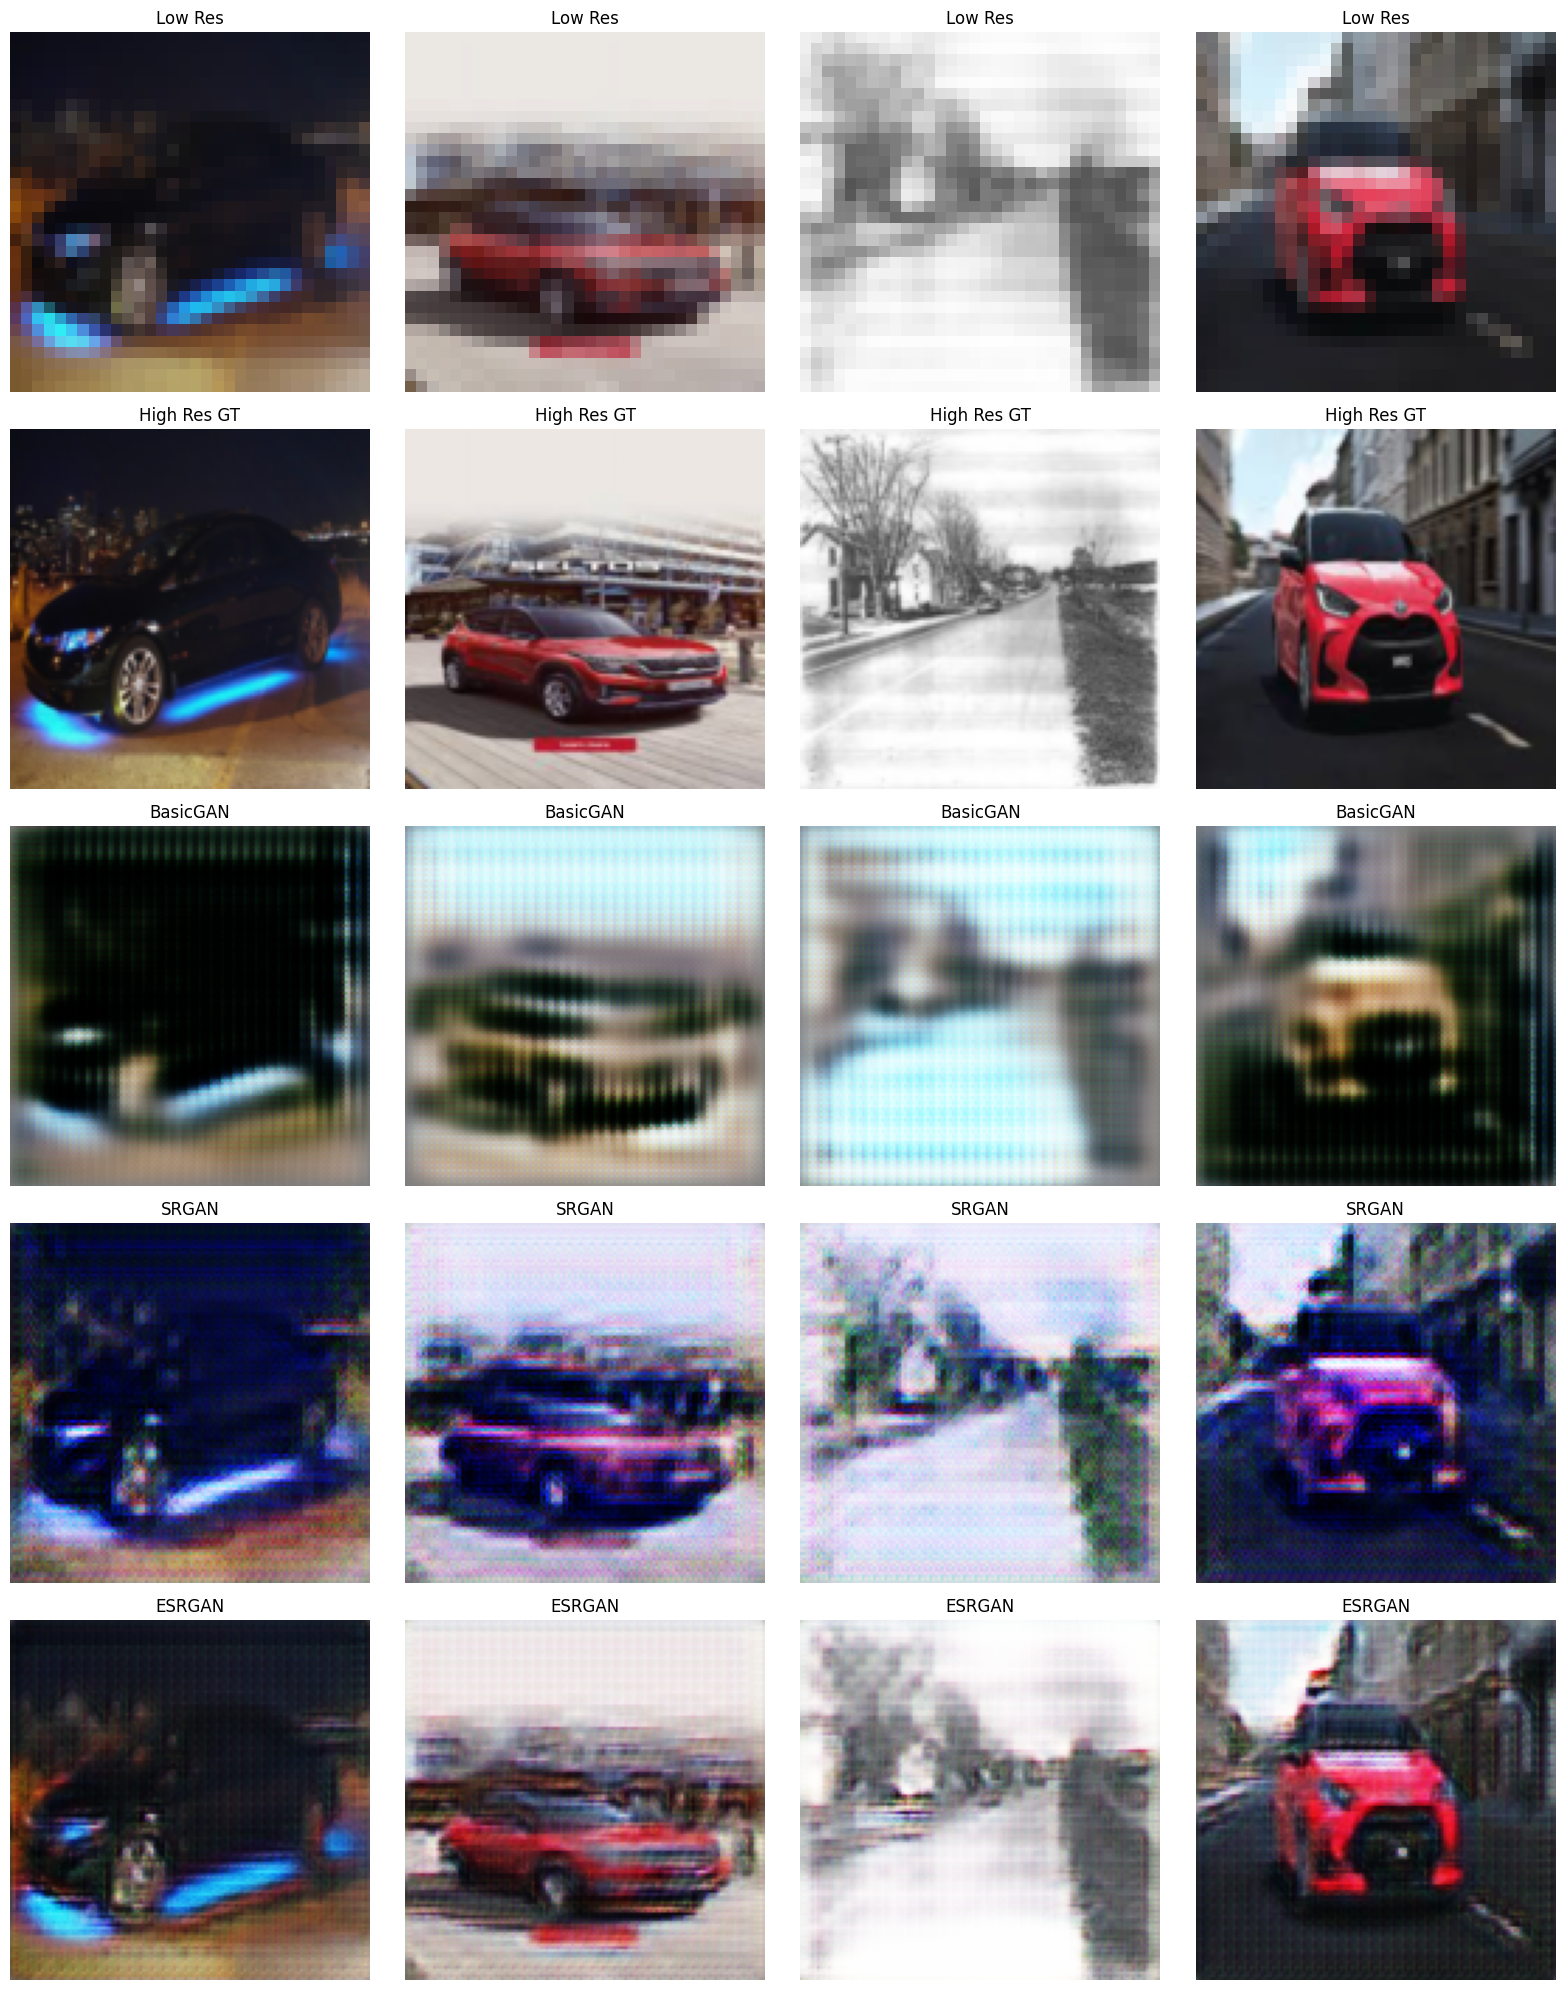

In [21]:
def show_results(models_dict, n=4):
    lr_imgs, hr_imgs = next(iter(val_dl))
    lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)

    rows = 2 + len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(4*n, 4*rows))

    def to_np(t): return (t.cpu().clamp(-1, 1).permute(1, 2, 0).numpy() * 0.5 + 0.5)

    for i in range(n):
        axes[0, i].imshow(to_np(lr_imgs[i])); axes[0, i].set_title('Low Res');     axes[0, i].axis('off')
        axes[1, i].imshow(to_np(hr_imgs[i])); axes[1, i].set_title('High Res GT'); axes[1, i].axis('off')

    for row, (name, model) in enumerate(models_dict.items(), start=2):
        model.eval()
        with torch.no_grad(): sr = model(lr_imgs)
        for i in range(n):
            axes[row, i].imshow(to_np(sr[i]))
            axes[row, i].set_title(name); axes[row, i].axis('off')

    plt.tight_layout(); plt.show()

show_results({'BasicGAN': basic_G, 'SRGAN': srgan_G, 'ESRGAN': esrgan_G})


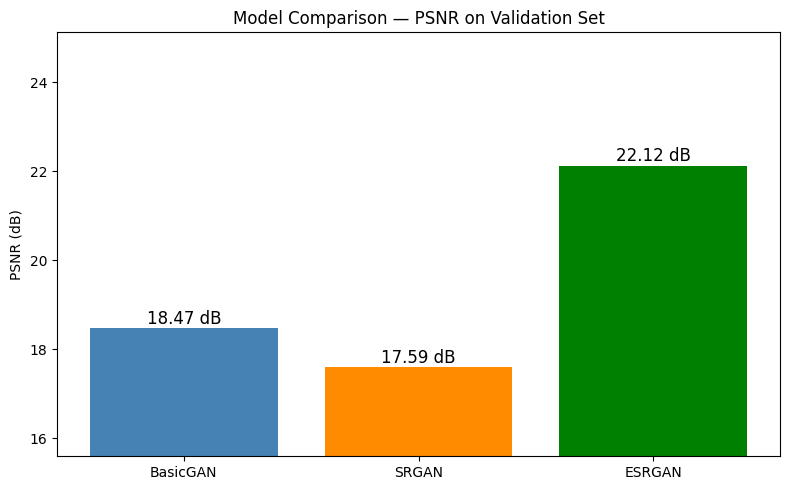

In [22]:
models_dict = {'BasicGAN': basic_G, 'SRGAN': srgan_G, 'ESRGAN': esrgan_G}
psnrs       = [psnr_basic, psnr_srgan, psnr_esrgan]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_dict.keys(), psnrs, color=['steelblue', 'darkorange', 'green'])
for bar, val in zip(bars, psnrs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f} dB', ha='center', fontsize=12)
plt.ylabel('PSNR (dB)'); plt.title('Model Comparison — PSNR on Validation Set')
plt.ylim(min(psnrs)-2, max(psnrs)+3); plt.tight_layout(); plt.show()


In [23]:
# Models are saved both locally (/content/) and to your Drive for persistence.
SAVE_DIR = '/content/drive/MyDrive/sr_models'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in [('basic_gan_generator', basic_G),
                    ('srgan_generator',      srgan_G),
                    ('esrgan_generator',     esrgan_G)]:
    local_path = f'/content/{name}.pth'
    drive_path = f'{SAVE_DIR}/{name}.pth'
    torch.save(model.state_dict(), local_path)
    torch.save(model.state_dict(), drive_path)
    print(f'Saved {name} → {drive_path}')


Saved basic_gan_generator → /content/drive/MyDrive/sr_models/basic_gan_generator.pth
Saved srgan_generator → /content/drive/MyDrive/sr_models/srgan_generator.pth
Saved esrgan_generator → /content/drive/MyDrive/sr_models/esrgan_generator.pth


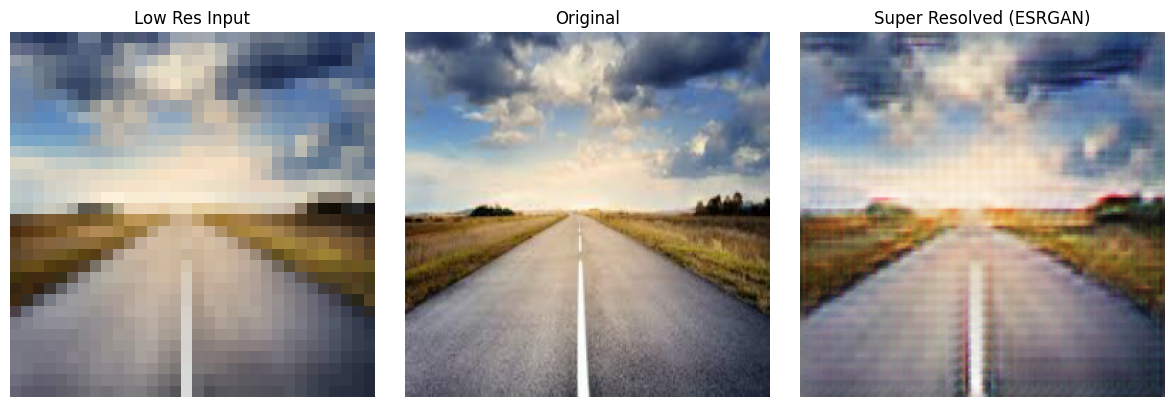

In [24]:
def super_resolve_image(model, image_path):
    """Super-resolve a single image and display LR / original / SR side-by-side."""
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((LOW_RES, LOW_RES)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    lr_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        # FIX: Tanh output is in [-1,1]; denorm to [0,1] correctly
        sr_tensor = model(lr_tensor).squeeze(0).cpu().clamp(-1, 1)
        sr_np     = (sr_tensor.permute(1, 2, 0).numpy() + 1.0) / 2.0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img.resize((LOW_RES, LOW_RES), Image.BICUBIC))
    axes[0].set_title('Low Res Input'); axes[0].axis('off')
    axes[1].imshow(img)
    axes[1].set_title('Original');      axes[1].axis('off')
    axes[2].imshow(sr_np)
    axes[2].set_title('Super Resolved (ESRGAN)'); axes[2].axis('off')
    plt.tight_layout(); plt.show()

# Run on a validation sample
sample_images = [f for f in os.listdir(VAL_HIGH)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if sample_images:
    super_resolve_image(esrgan_G, os.path.join(VAL_HIGH, sample_images[0]))
else:
    print('No validation images found — check VAL_HIGH path.')
